In [38]:
import pandas as pd

print("working")

working


In [39]:
df = pd.read_csv("Sales.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [41]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [42]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [43]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

## Initial Data Exploration

Initial investigation was performed to understand dataset structure, identify missing values, and examine available business attributes for analysis.

In [44]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.month_name()

df['Year'] = df['Order Date'].dt.year

In [45]:
df[['Order Date','Month','Year']].head()

,Order Date,Month,Year
0,2016-11-08,November,2016
1,2016-11-08,November,2016
2,2016-06-12,June,2016
3,2015-10-11,October,2015
4,2015-10-11,October,2015


In [46]:
monthly_sales = df.groupby('Month')['Sales'].sum()

In [47]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = monthly_sales.reindex(month_order)

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

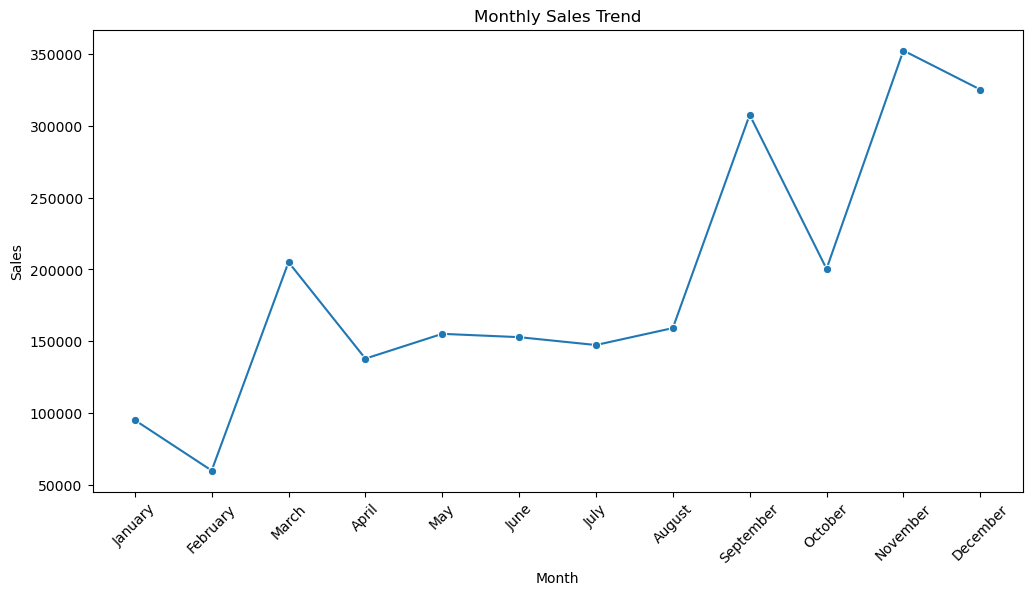

In [49]:
plt.figure(figsize=(12,6))

sns.lineplot(x=monthly_sales.index,
             y=monthly_sales.values,
             marker='o')

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()


In [50]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

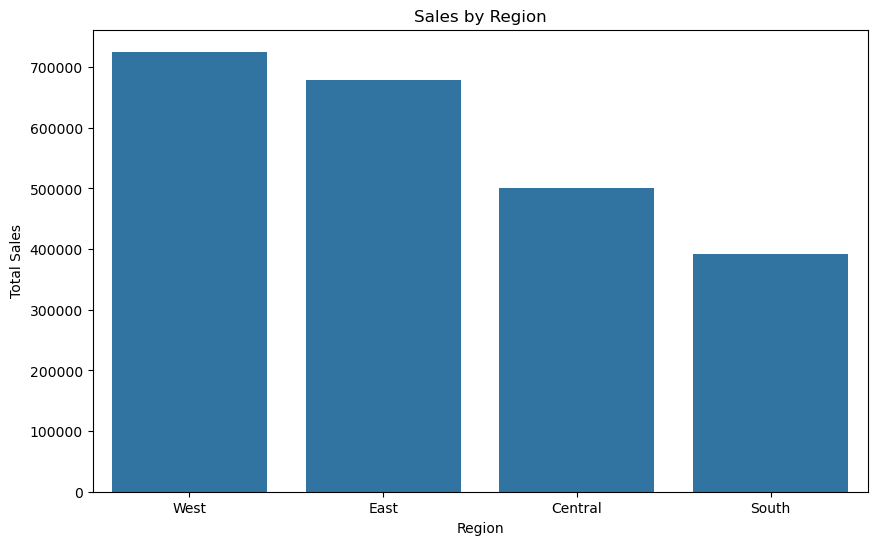

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(x=region_sales.index,
            y=region_sales.values)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

### Observation

Regional sales analysis was performed to identify geographical business performance differences. Certain regions generated significantly higher sales, indicating stronger market presence and customer demand in those areas.

In [52]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

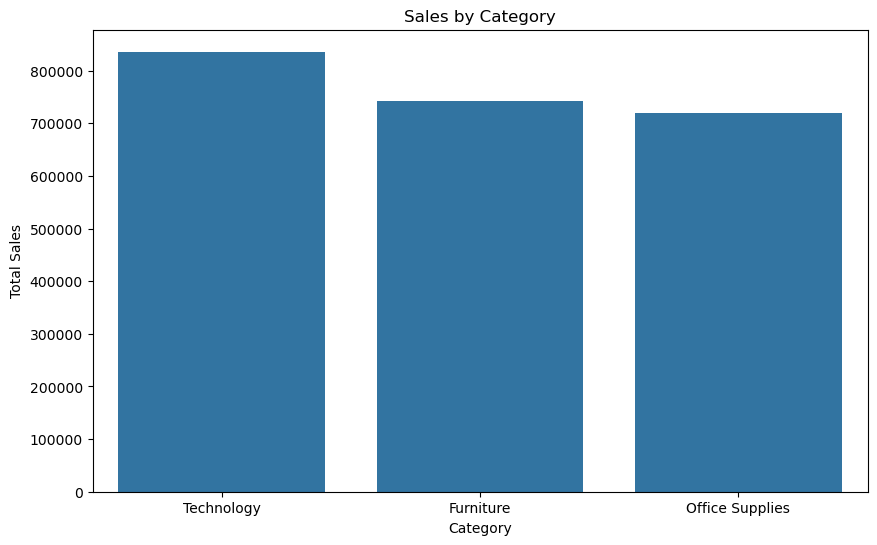

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(x=category_sales.index,
            y=category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

### Observation

Category-wise sales analysis revealed differences in product performance across major business categories. High-performing categories contributed significantly to overall revenue generation and may represent core business strengths.

In [54]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

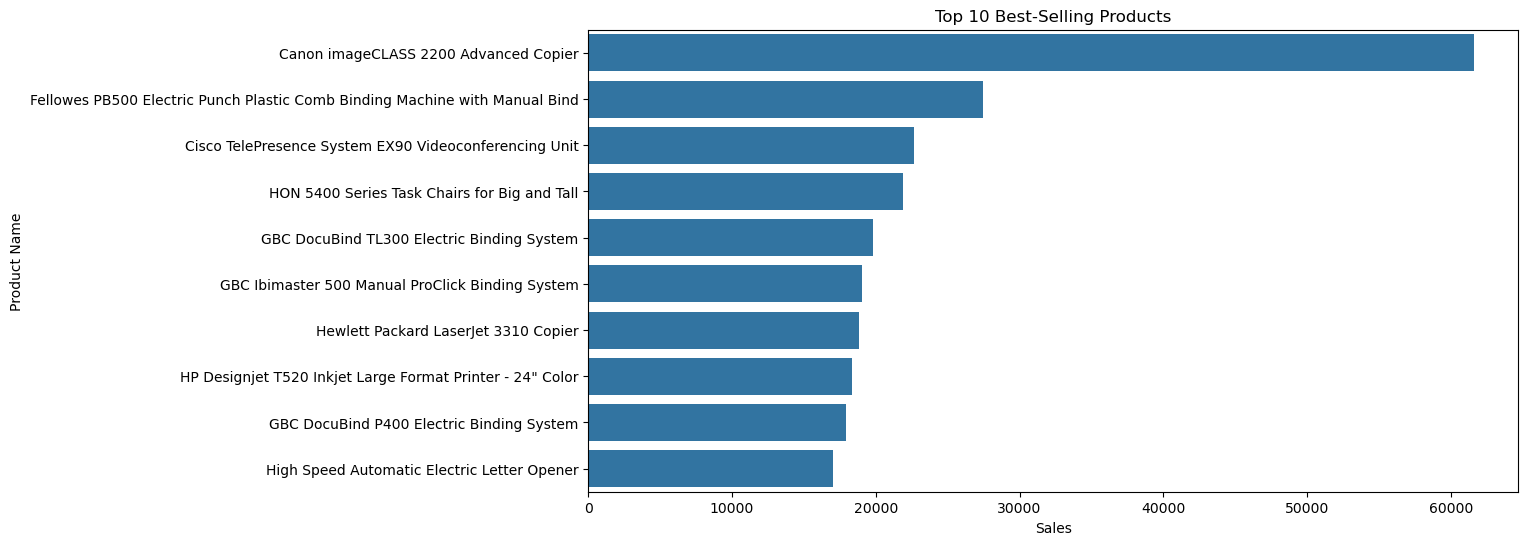

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(x=top_products.values,
            y=top_products.index)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.show()

### Observation

Top-selling product analysis identified products contributing the highest revenue to the business. These products may represent strong customer demand, effective pricing strategies, or successful market positioning.

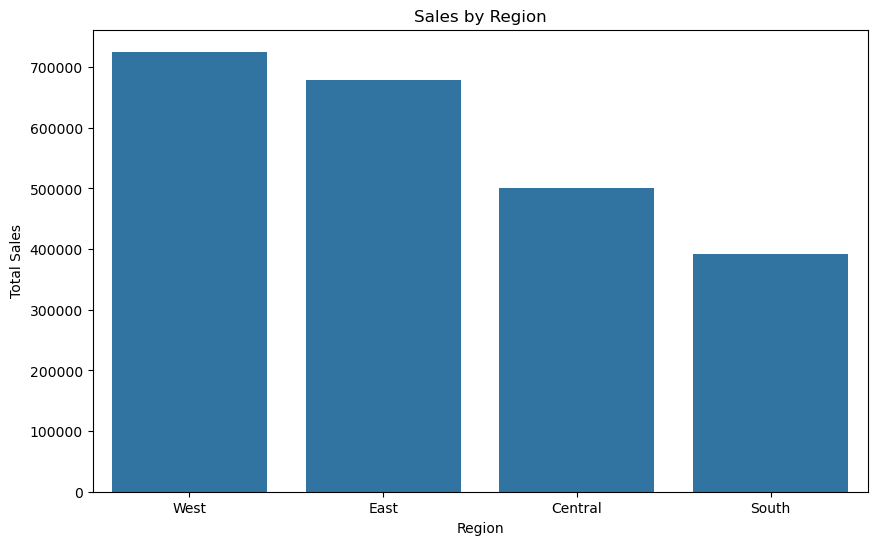

In [56]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

### Observation

Regional analysis was performed to compare business performance across geographical markets. Regions with higher sales may indicate stronger customer demand and market penetration.

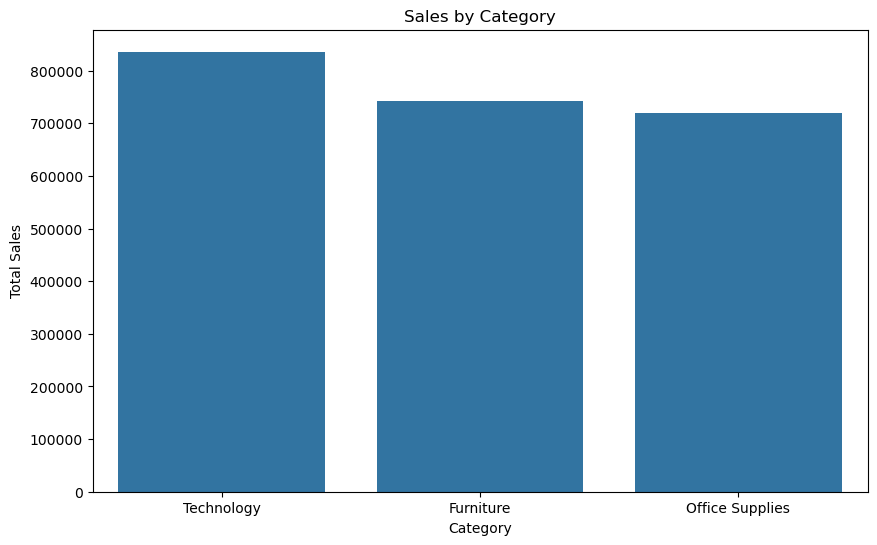

In [57]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

### Observation

Category-wise sales comparison highlighted differences in product performance. High-performing categories contributed significantly to overall business revenue.

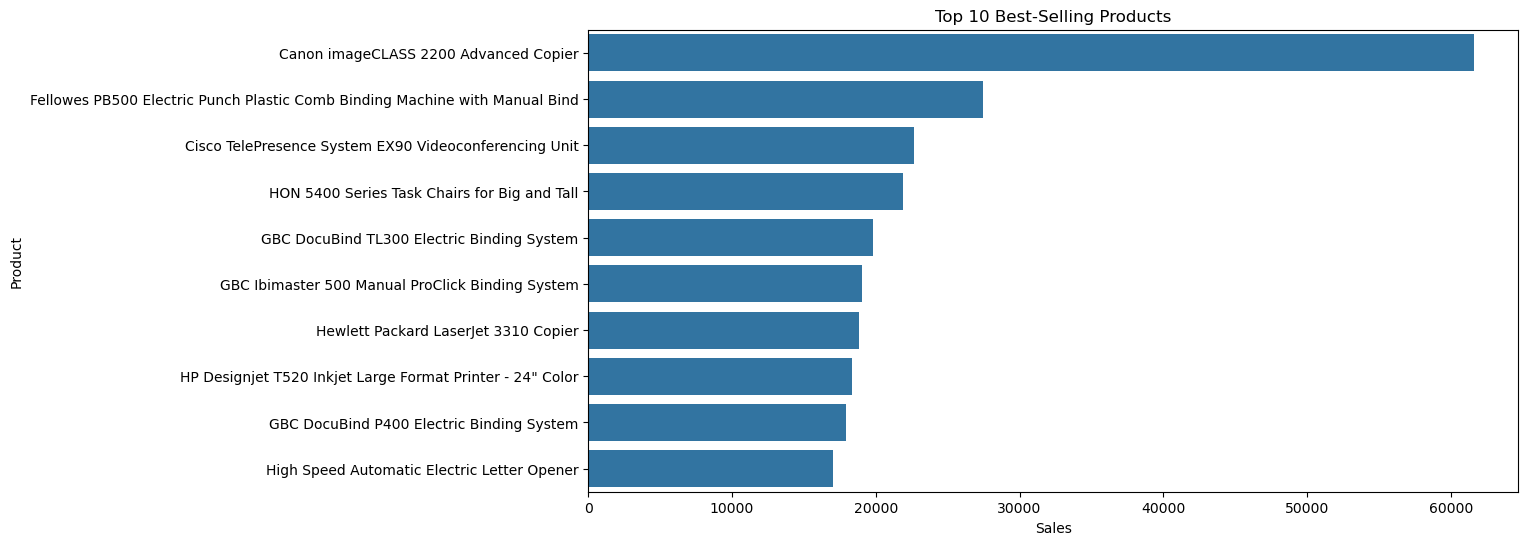

In [58]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

### Observation

Top-selling products contributed a large share of total sales and may represent products with strong customer demand or premium pricing.

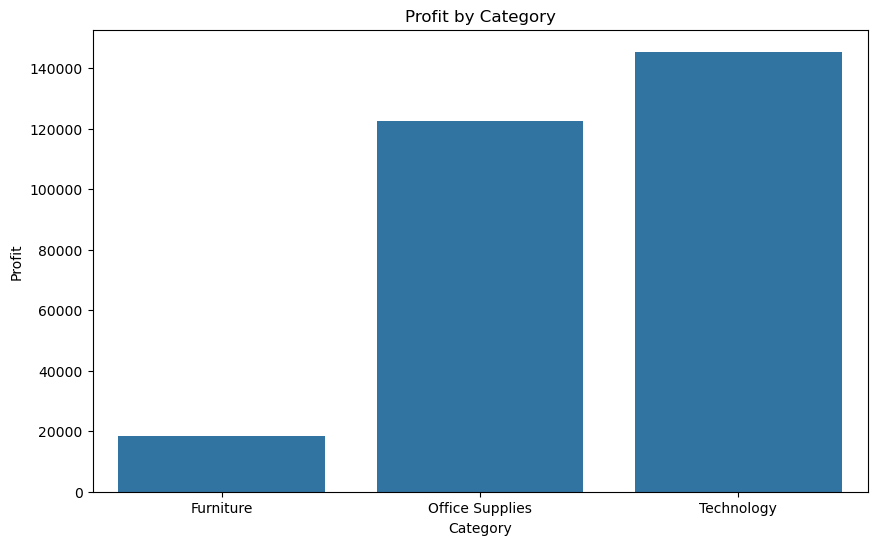

In [59]:
profit_category = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(10,6))

sns.barplot(
    x=profit_category.index,
    y=profit_category.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

### Observation

Profit analysis revealed whether high sales translated into business profitability. Categories with strong sales but weak profit may require pricing or cost optimization strategies.

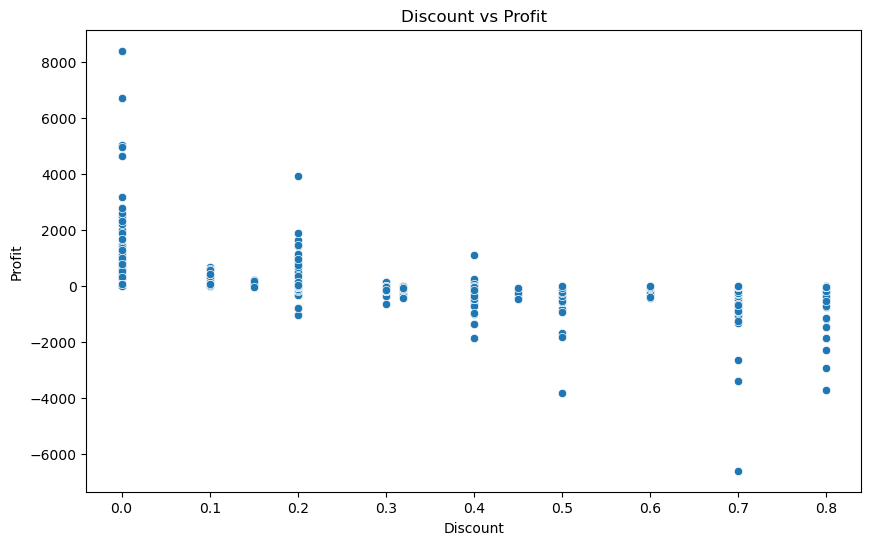

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Discount'],
    y=df['Profit']
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Observation

This analysis was performed to investigate whether aggressive discounting positively influenced profitability. High discount levels may increase sales volume but can potentially reduce overall profit margins.

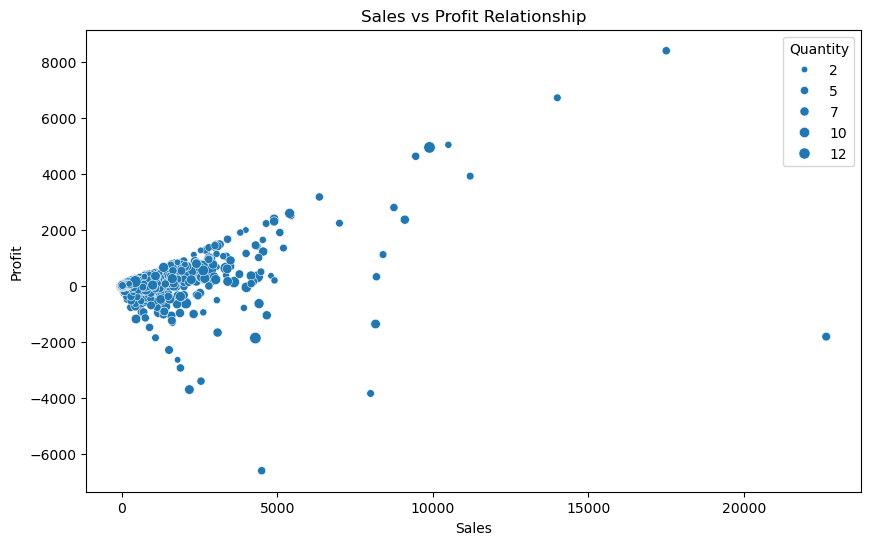

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Sales'],
    y=df['Profit'],
    size=df['Quantity']
)

plt.title("Sales vs Profit Relationship")

plt.show()

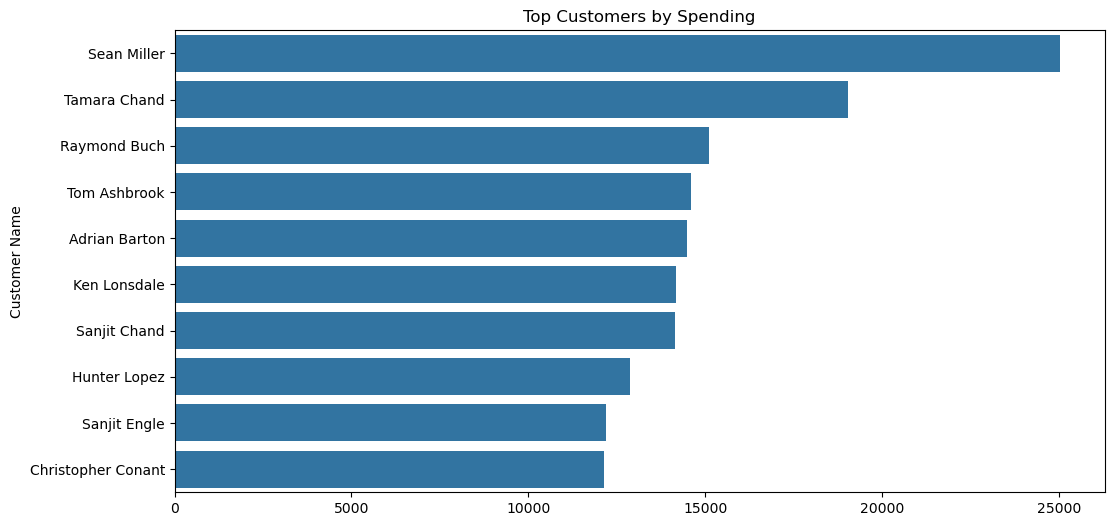

In [62]:
top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top Customers by Spending")

plt.show()

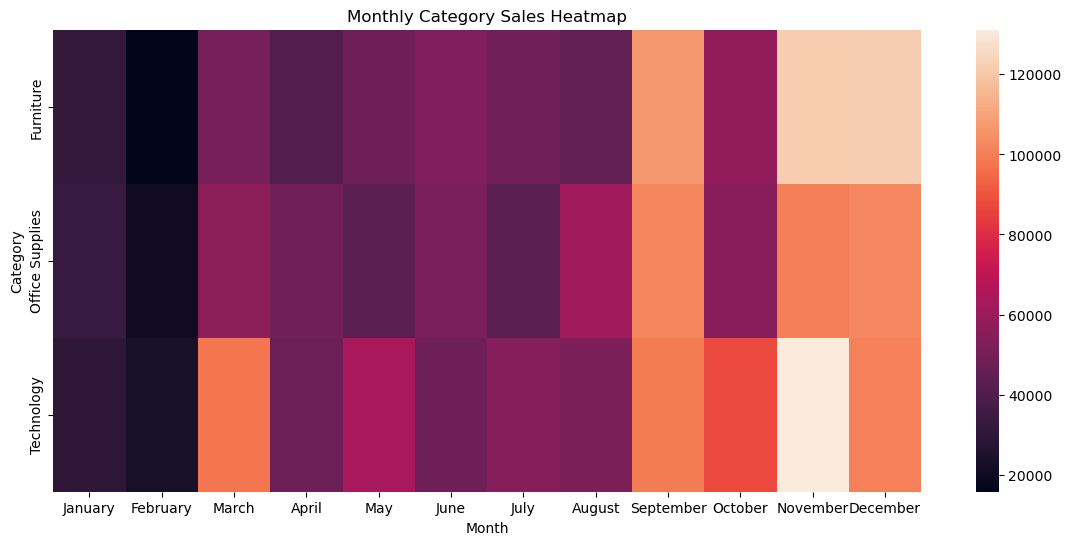

In [63]:
pivot = df.pivot_table(
    values='Sales',
    index='Category',
    columns='Month',
    aggfunc='sum'
)

pivot = pivot[[
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]]

plt.figure(figsize=(14,6))

sns.heatmap(pivot)

plt.title("Monthly Category Sales Heatmap")

plt.show()

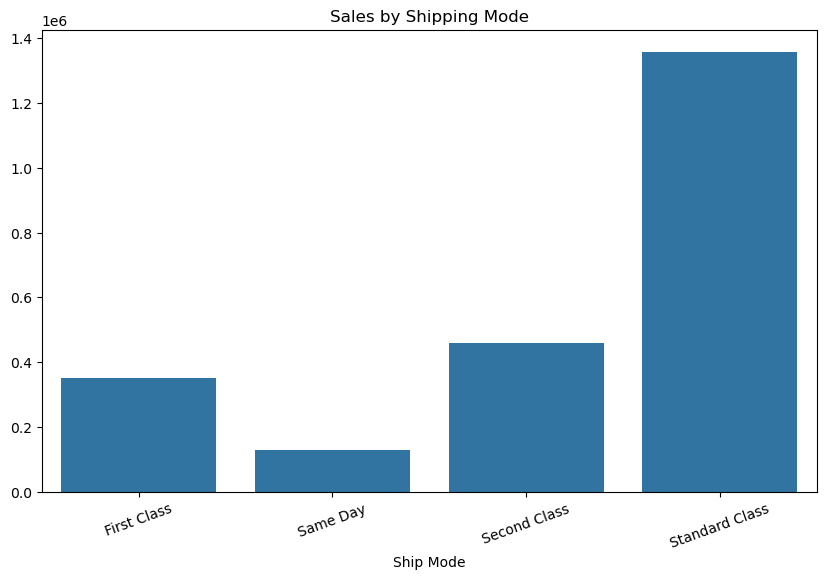

In [64]:
ship_sales = df.groupby('Ship Mode')['Sales'].sum()

plt.figure(figsize=(10,6))

sns.barplot(
    x=ship_sales.index,
    y=ship_sales.values
)

plt.xticks(rotation=20)

plt.title("Sales by Shipping Mode")

plt.show()

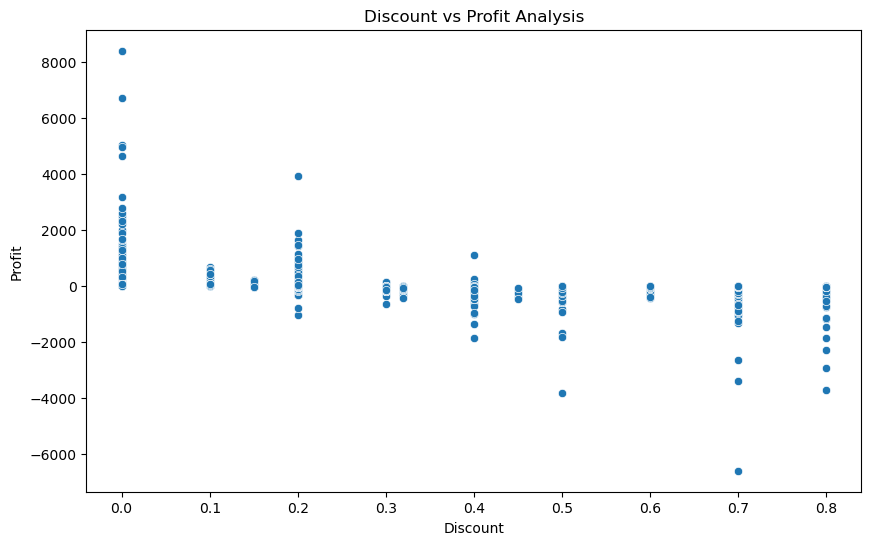

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Discount'],
    y=df['Profit']
)

plt.title("Discount vs Profit Analysis")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Observation

This analysis explored the relationship between discounts and profitability. Higher discount levels may increase sales volume, but excessive discounting can negatively impact profit margins.

In [66]:
pivot = df.pivot_table(
    values='Sales',
    index='Category',
    columns='Month',
    aggfunc='sum'
)

In [67]:
pivot = pivot[
[
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]
]

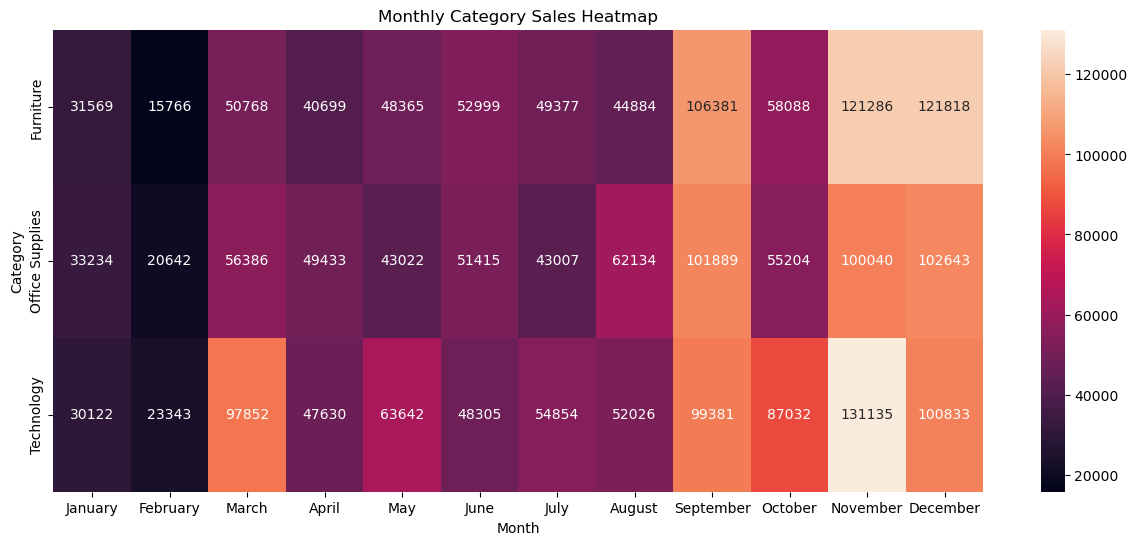

In [68]:
plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f'
)

plt.title("Monthly Category Sales Heatmap")

plt.show()

# Final Conclusion

The sales dashboard analysis revealed key business insights regarding customer purchasing behavior, regional performance, category contribution, and profitability trends.

Key findings:

- Sales performance varied across regions and product categories.
- Certain products contributed disproportionately to total revenue.
- Discount levels influenced profitability patterns.
- Seasonal trends were observed across categories.
- Profitability and sales volume were not always directly proportional.

These insights can support strategic business decisions related to pricing, inventory planning, and market focus.